# Model Comparison Notebook

Use this notebook to compare `GPT`, `Gemini`, and `Grok` for a single pipeline run folder.

Expected run structure:
- `runs/<RUN_FOLDER_NAME>/comparison_metrics.csv`


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)


## 1) Set Run Folder

Set this to the run you want to analyze, for example: `run_20260427_084418`.

In [2]:
RUN_FOLDER_NAME = 'run_20260427_084418'  # change this
RUN_DIR = Path('runs') / RUN_FOLDER_NAME
COMPARISON_CSV = RUN_DIR / 'comparison_metrics.csv'

print('Run dir:', RUN_DIR.resolve())
print('CSV exists:', COMPARISON_CSV.exists())
COMPARISON_CSV


Run dir: /Users/mariadecaro/Desktop/Cornell Tech/- Spring 2026/tech, media, democracy/TMD_Final/runs/run_20260427_084418
CSV exists: True


PosixPath('runs/run_20260427_084418/comparison_metrics.csv')

In [3]:
if not COMPARISON_CSV.exists():
    raise FileNotFoundError(f'Missing file: {COMPARISON_CSV}')

df = pd.read_csv(COMPARISON_CSV)

numeric_cols = [
    'coverage_score', 'covered_points', 'partial_points', 'missing_points', 'total_key_points',
    'sentiment_shift', 'keyword_overlap', 'similarity',
    'faithfulness_score', 'supported', 'contradictions', 'neutral',
    'total_summary_sentences', 'contradiction_rate'
]

for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

print('Rows:', len(df))
print('Models:', sorted(df['Model'].dropna().unique().tolist()))
df.head()


Rows: 3
Models: ['GPT', 'Gemini', 'Grok']


,Genre,Article Name,Model,coverage_score,covered_points,partial_points,missing_points,total_key_points,sentiment_shift,keyword_overlap,similarity,framing_label,missing_important_topics,faithfulness_score,supported,contradictions,neutral,total_summary_sentences,contradiction_rate,sentence_level_nli,point_results,note
0,Health,Aspirin can reduce the risk of cancer - and we...,GPT,0.5000,0,3,0,3,0.0625,0.2,0.8382,Major shift,bowel cancer | cancer depending | causes lynch...,0.7500,2,0,2,4,0.0,"[{""summary_sentence"": ""The article discusses t...","[{""key_point"": ""A man, James, who's whole fami...",NaN
1,Health,Aspirin can reduce the risk of cancer - and we...,Gemini,0.5000,0,3,0,3,0.6626,0.2,0.7920,Major shift,cancer depending | causes lynch | clinical gen...,0.8000,3,0,2,5,0.0,"[{""summary_sentence"": ""The article highlights ...","[{""key_point"": ""A man, James, who's whole fami...",NaN
2,Health,Aspirin can reduce the risk of cancer - and we...,Grok,0.8333,2,1,0,3,0.1287,0.2,0.8569,Major shift,cancer depending | causes lynch | clinical gen...,0.6667,2,0,4,6,0.0,"[{""summary_sentence"": ""**Summary:**\n\nAspirin...","[{""key_point"": ""A man, James, who's whole fami...",NaN


## 2) Per-Article Comparison (Side by Side)

In [4]:
article_cols = ['Genre', 'Article Name', 'Model', 'coverage_score', 'keyword_overlap', 'similarity', 'faithfulness_score', 'contradiction_rate', 'framing_label']
article_view = df[[c for c in article_cols if c in df.columns]].copy()
article_view.sort_values(['Genre', 'Article Name', 'Model'])


,Genre,Article Name,Model,coverage_score,keyword_overlap,similarity,faithfulness_score,contradiction_rate,framing_label
0,Health,Aspirin can reduce the risk of cancer - and we...,GPT,0.5000,0.2,0.8382,0.7500,0.0,Major shift
1,Health,Aspirin can reduce the risk of cancer - and we...,Gemini,0.5000,0.2,0.7920,0.8000,0.0,Major shift
2,Health,Aspirin can reduce the risk of cancer - and we...,Grok,0.8333,0.2,0.8569,0.6667,0.0,Major shift


## 3) Aggregate Model Scores

Higher is better for:
- `coverage_score`
- `keyword_overlap`
- `similarity`
- `faithfulness_score`

Lower is better for:
- `contradiction_rate`
- `abs_sentiment_shift` (smaller sentiment drift)

In [5]:
agg = df.copy()
agg['abs_sentiment_shift'] = agg['sentiment_shift'].abs()

model_summary = agg.groupby('Model', dropna=False).agg({
    'coverage_score': 'mean',
    'keyword_overlap': 'mean',
    'similarity': 'mean',
    'faithfulness_score': 'mean',
    'contradiction_rate': 'mean',
    'abs_sentiment_shift': 'mean',
}).reset_index()

model_summary = model_summary.sort_values(['faithfulness_score', 'coverage_score', 'similarity'], ascending=False)
model_summary


,Model,coverage_score,keyword_overlap,similarity,faithfulness_score,contradiction_rate,abs_sentiment_shift
1,Gemini,0.5000,0.2,0.7920,0.8000,0.0,0.6626
0,GPT,0.5000,0.2,0.8382,0.7500,0.0,0.0625
2,Grok,0.8333,0.2,0.8569,0.6667,0.0,0.1287


## 4) Composite Ranking (Adjustable Weights)

In [6]:
weights = {
    'coverage_score': 0.35,
    'faithfulness_score': 0.35,
    'keyword_overlap': 0.15,
    'similarity': 0.10,
    'contradiction_rate': 0.05,  # subtract
}

rank_df = model_summary.copy()
rank_df['composite_score'] = (
    weights['coverage_score'] * rank_df['coverage_score']
    + weights['faithfulness_score'] * rank_df['faithfulness_score']
    + weights['keyword_overlap'] * rank_df['keyword_overlap']
    + weights['similarity'] * rank_df['similarity']
    - weights['contradiction_rate'] * rank_df['contradiction_rate']
)

rank_df = rank_df.sort_values('composite_score', ascending=False)
rank_df


,Model,coverage_score,keyword_overlap,similarity,faithfulness_score,contradiction_rate,abs_sentiment_shift,composite_score
2,Grok,0.8333,0.2,0.8569,0.6667,0.0,0.1287,0.64069
1,Gemini,0.5000,0.2,0.7920,0.8000,0.0,0.6626,0.56420
0,GPT,0.5000,0.2,0.8382,0.7500,0.0,0.0625,0.55132


## 5) Charts

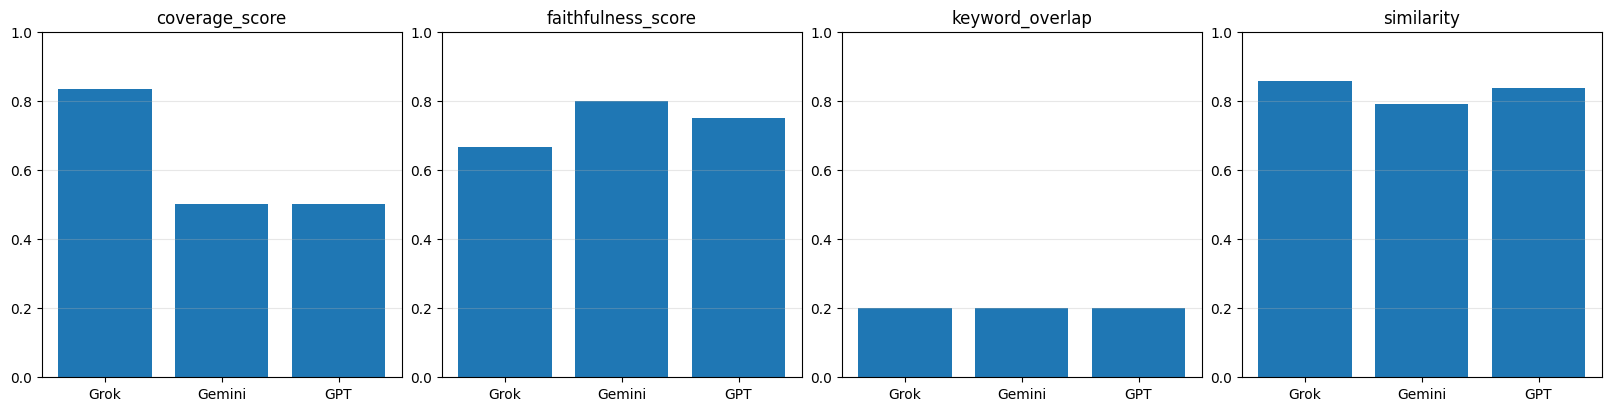

In [7]:
plot_cols = ['coverage_score', 'faithfulness_score', 'keyword_overlap', 'similarity']
fig, axes = plt.subplots(1, len(plot_cols), figsize=(4 * len(plot_cols), 4), constrained_layout=True)

for i, col in enumerate(plot_cols):
    ax = axes[i]
    ax.bar(rank_df['Model'], rank_df[col])
    ax.set_title(col)
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)

plt.show()


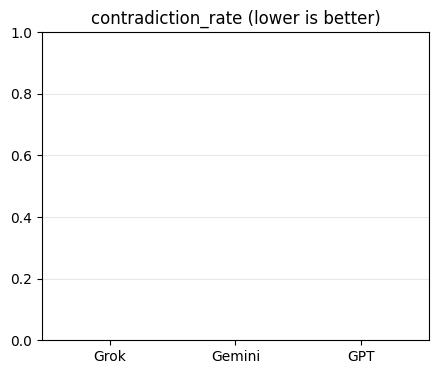

In [8]:
# Contradiction rate (lower is better)
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(rank_df['Model'], rank_df['contradiction_rate'])
ax.set_title('contradiction_rate (lower is better)')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.show()


## 6) Export Ranked Summary CSV

In [9]:
out_csv = RUN_DIR / 'model_ranking_summary.csv'
rank_df.to_csv(out_csv, index=False)
print('Saved:', out_csv)
rank_df


Saved: runs/run_20260427_084418/model_ranking_summary.csv


,Model,coverage_score,keyword_overlap,similarity,faithfulness_score,contradiction_rate,abs_sentiment_shift,composite_score
2,Grok,0.8333,0.2,0.8569,0.6667,0.0,0.1287,0.64069
1,Gemini,0.5000,0.2,0.7920,0.8000,0.0,0.6626,0.56420
0,GPT,0.5000,0.2,0.8382,0.7500,0.0,0.0625,0.55132


## 7) Genre-Aware Comparison

This section compares model performance within each `Genre` so you can see whether one model is stronger in Health, Tech, or Politics.

In [ ]:
genre_model_summary = (
    df.assign(abs_sentiment_shift=df['sentiment_shift'].abs())
      .groupby(['Genre', 'Model'], dropna=False)[[
          'coverage_score', 'faithfulness_score', 'keyword_overlap',
          'similarity', 'contradiction_rate', 'abs_sentiment_shift'
      ]]
      .mean()
      .reset_index()
)

genre_model_summary.sort_values(['Genre', 'Model'])


In [ ]:
# Pivot view: each row is Genre, columns are metric x model
genre_pivot = genre_model_summary.pivot_table(
    index='Genre',
    columns='Model',
    values=['coverage_score', 'faithfulness_score', 'keyword_overlap', 'similarity', 'contradiction_rate']
)
genre_pivot


In [ ]:
# Per-genre ranking using the same weighted composite logic
weights = {
    'coverage_score': 0.35,
    'faithfulness_score': 0.35,
    'keyword_overlap': 0.15,
    'similarity': 0.10,
    'contradiction_rate': 0.05,  # subtract
}

genre_rank = genre_model_summary.copy()
genre_rank['composite_score'] = (
    weights['coverage_score'] * genre_rank['coverage_score']
    + weights['faithfulness_score'] * genre_rank['faithfulness_score']
    + weights['keyword_overlap'] * genre_rank['keyword_overlap']
    + weights['similarity'] * genre_rank['similarity']
    - weights['contradiction_rate'] * genre_rank['contradiction_rate']
)

genre_rank = genre_rank.sort_values(['Genre', 'composite_score'], ascending=[True, False])
genre_rank


In [ ]:
# Chart: composite score by genre
genres = sorted(genre_rank['Genre'].dropna().unique().tolist())
n = len(genres)
fig, axes = plt.subplots(1, max(1, n), figsize=(5 * max(1, n), 4), constrained_layout=True)
if n == 1:
    axes = [axes]

for i, g in enumerate(genres):
    sub = genre_rank[genre_rank['Genre'] == g].sort_values('composite_score', ascending=False)
    ax = axes[i]
    ax.bar(sub['Model'], sub['composite_score'])
    ax.set_title(f'{g}: composite_score')
    ax.grid(axis='y', alpha=0.3)

plt.show()


In [ ]:
# Optional export
genre_csv = RUN_DIR / 'genre_model_ranking_summary.csv'
genre_rank.to_csv(genre_csv, index=False)
print('Saved:', genre_csv)
